# 02 — Feature Engineering
**Project:** Santander Customer Transaction Prediction  
**Inputs:** `data/raw/train.csv`  
**Outputs:** `data/processed/X_train.csv`, `X_val.csv`, `y_train.csv`, `y_val.csv`

---
### Notebook Structure
1. Setup & Data Loading
2. Train / Validation Split (stratified 80/20)
3. Aggregate Features (row-wise statistics)
4. Feature Scaling (RobustScaler for Logistic Regression)
5. Class Imbalance Strategy
6. Save Processed Data
7. Feature Engineering Summary

## 1. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED      = 42
TEST_SIZE = 0.2
DATA_PATH = '../data/train.csv'
OUT_DIR   = '../data/processed'
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
df = pd.read_csv(DATA_PATH)
feature_cols = [c for c in df.columns if c.startswith('var_')]

X = df[feature_cols].copy()
y = df['target'].copy()

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Features: {len(feature_cols)}')
print(f'Target distribution: {y.value_counts().to_dict()}')

Loaded: 200,000 rows × 202 columns
Features: 200
Target distribution: {0: 179902, 1: 20098}


## 2. Train / Validation Split

We split **before** any transformations to avoid data leakage.

**Why stratify?**  
With a 90/10 class imbalance, a random split could put too many positives in one set by chance. `stratify=y` guarantees both sets preserve the original 90/10 ratio.

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y          # preserves class ratio in both sets
)

print('=== Split Summary ===')
print(f'X_train: {X_train.shape}  |  X_val: {X_val.shape}')
print(f'y_train positive rate: {y_train.mean()*100:.2f}%')
print(f'y_val   positive rate: {y_val.mean()*100:.2f}%')
print('\nClass distribution preserved ✓' if abs(y_train.mean() - y_val.mean()) < 0.001 else 'Warning: distributions differ')

=== Split Summary ===
X_train: (160000, 200)  |  X_val: (40000, 200)
y_train positive rate: 10.05%
y_val   positive rate: 10.05%

Class distribution preserved ✓


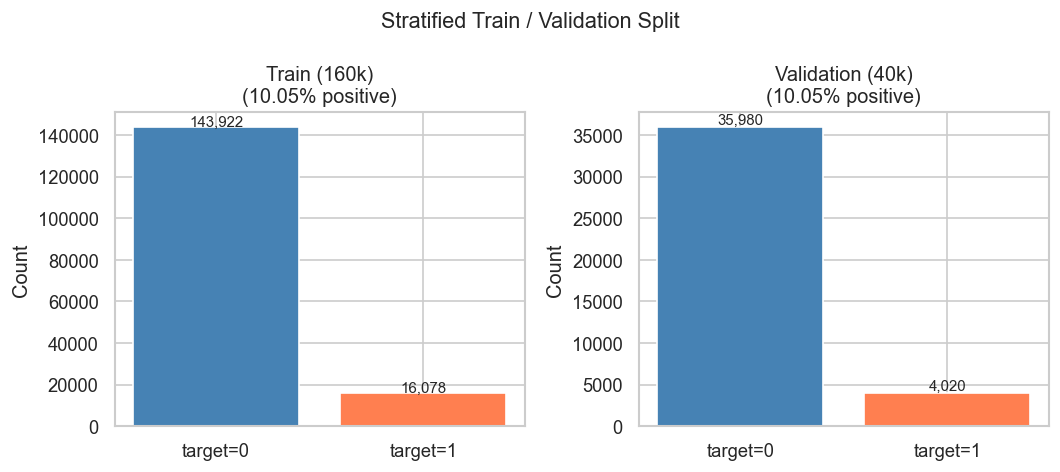

In [6]:
# Visualise the split
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (label, ys) in zip(axes, [('Train (160k)', y_train), ('Validation (40k)', y_val)]):
    counts = ys.value_counts()
    ax.bar(['target=0', 'target=1'], counts.values,
           color=['steelblue', 'coral'], edgecolor='white')
    ax.set_title(f'{label}\n({ys.mean()*100:.2f}% positive)')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Stratified Train / Validation Split', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks_images/08_train_val_split.png', bbox_inches='tight')
plt.show()

## 3. Aggregate Features (row-wise statistics)

Since features are independent and anonymized, we can create **row-wise summary statistics** across all 200 features.  
These capture the overall "profile" of a customer across all variables.

> ⚠️ We compute these on train and val **separately** — but since these are row-wise statistics (not fitted on train data), there is no leakage risk here.

In [7]:
def add_aggregate_features(df_features):
    """Add row-wise aggregate statistics across all 200 features."""
    agg = pd.DataFrame(index=df_features.index)
    agg['row_mean'] = df_features.mean(axis=1)
    agg['row_std']  = df_features.std(axis=1)
    agg['row_min']  = df_features.min(axis=1)
    agg['row_max']  = df_features.max(axis=1)
    agg['row_range']= df_features.max(axis=1) - df_features.min(axis=1)
    agg['row_skew'] = df_features.skew(axis=1)
    return pd.concat([df_features, agg], axis=1)

X_train_eng = add_aggregate_features(X_train)
X_val_eng   = add_aggregate_features(X_val)

new_features = ['row_mean', 'row_std', 'row_min', 'row_max', 'row_range', 'row_skew']
print(f'Features before: {X_train.shape[1]}')
print(f'Features after:  {X_train_eng.shape[1]}')
print(f'\nNew aggregate features added: {new_features}')

Features before: 200
Features after:  206

New aggregate features added: ['row_mean', 'row_std', 'row_min', 'row_max', 'row_range', 'row_skew']


Aggregate feature correlations with target:
row_max      0.0182
row_std      0.0180
row_mean     0.0179
row_skew     0.0141
row_range    0.0111
row_min      0.0017


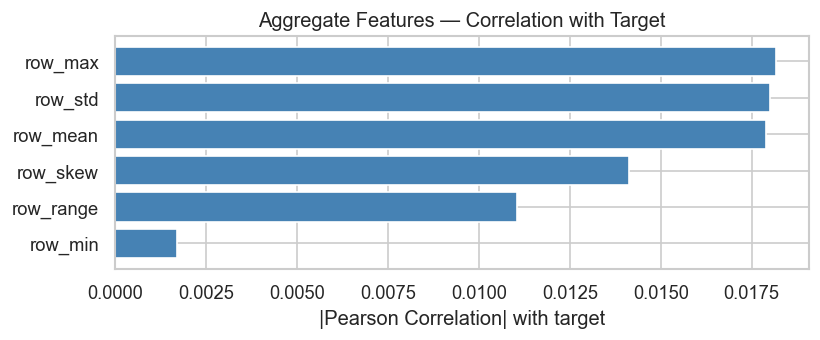

In [8]:
# Check correlation of new features with target
corr_new = X_train_eng[new_features].corrwith(y_train).abs().sort_values(ascending=False)

print('Aggregate feature correlations with target:')
print(corr_new.round(4).to_string())

plt.figure(figsize=(7, 3))
plt.barh(corr_new.index[::-1], corr_new.values[::-1], color='steelblue', edgecolor='white')
plt.xlabel('|Pearson Correlation| with target')
plt.title('Aggregate Features — Correlation with Target')
plt.tight_layout()
plt.savefig('../notebooks_images/09_aggregate_feature_corr.png', bbox_inches='tight')
plt.show()

## 4. Feature Scaling

**Why scale?**  
Logistic Regression uses gradient descent and is sensitive to feature magnitudes — without scaling, features with large ranges dominate the loss function.

**Why RobustScaler over StandardScaler?**  
RobustScaler uses the **median and IQR** instead of mean and std — making it less sensitive to the outliers we found in EDA.

| Scaler | Formula | Sensitive to outliers? |
|--------|---------|------------------------|
| StandardScaler | (x - mean) / std | Yes |
| RobustScaler | (x - median) / IQR | No |

> ⚠️ **Key rule:** Fit the scaler **only on X_train**, then apply (transform) to X_val.  
> Fitting on X_val would leak validation statistics into the pipeline.

In [9]:
scaler = RobustScaler()

# Fit ONLY on training data
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_eng),
    columns=X_train_eng.columns,
    index=X_train_eng.index
)

# Transform validation data using training scaler
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_eng),
    columns=X_val_eng.columns,
    index=X_val_eng.index
)

print('=== Scaling Verification ===')
print(f'X_train_scaled mean (should be ~0): {X_train_scaled.mean().mean():.4f}')
print(f'X_train_scaled std  (should be ~1): {X_train_scaled.std().mean():.4f}')
print(f'\nX_val_scaled mean (slight drift OK): {X_val_scaled.mean().mean():.4f}')
print(f'X_val_scaled std:                    {X_val_scaled.std().mean():.4f}')

=== Scaling Verification ===
X_train_scaled mean (should be ~0): 0.0008
X_train_scaled std  (should be ~1): 0.6844

X_val_scaled mean (slight drift OK): 0.0011
X_val_scaled std:                    0.6842


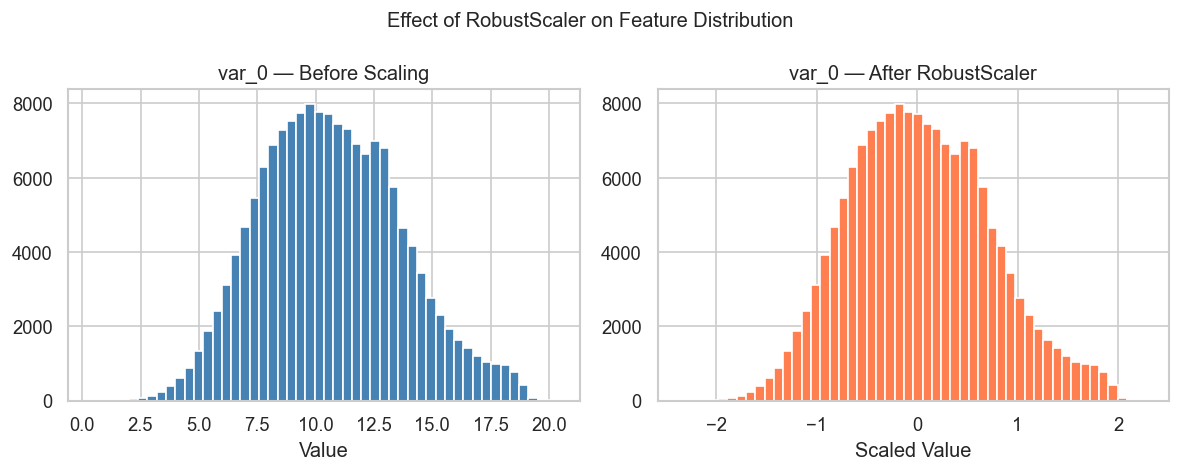

In [10]:
# Before vs after scaling — compare var_0
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(X_train['var_0'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('var_0 — Before Scaling')
axes[0].set_xlabel('Value')

axes[1].hist(X_train_scaled['var_0'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('var_0 — After RobustScaler')
axes[1].set_xlabel('Scaled Value')

plt.suptitle('Effect of RobustScaler on Feature Distribution', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks_images/10_scaling_effect.png', bbox_inches='tight')
plt.show()

## 5. Class Imbalance Strategy

We use `class_weight='balanced'` in our models instead of resampling the data.  

**How it works:**  
Sklearn automatically computes weights inversely proportional to class frequencies:

```
weight_class_0 = n_samples / (2 * n_class_0)  →  ~0.55
weight_class_1 = n_samples / (2 * n_class_1)  →  ~4.97
```

This means **errors on minority class (target=1) are penalized ~9× more** than errors on majority class — matching the class imbalance ratio.

In [11]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print('Computed class weights:')
for cls, w in class_weight_dict.items():
    print(f'  class {cls}: {w:.4f}')
print(f'\nRatio (class_1 / class_0): {weights[1]/weights[0]:.2f}x')
print('\nThis means: a wrong prediction on a positive sample costs',
      f'{weights[1]/weights[0]:.1f}x more than on a negative sample.')

Computed class weights:
  class 0: 0.5559
  class 1: 4.9757

Ratio (class_1 / class_0): 8.95x

This means: a wrong prediction on a positive sample costs 9.0x more than on a negative sample.


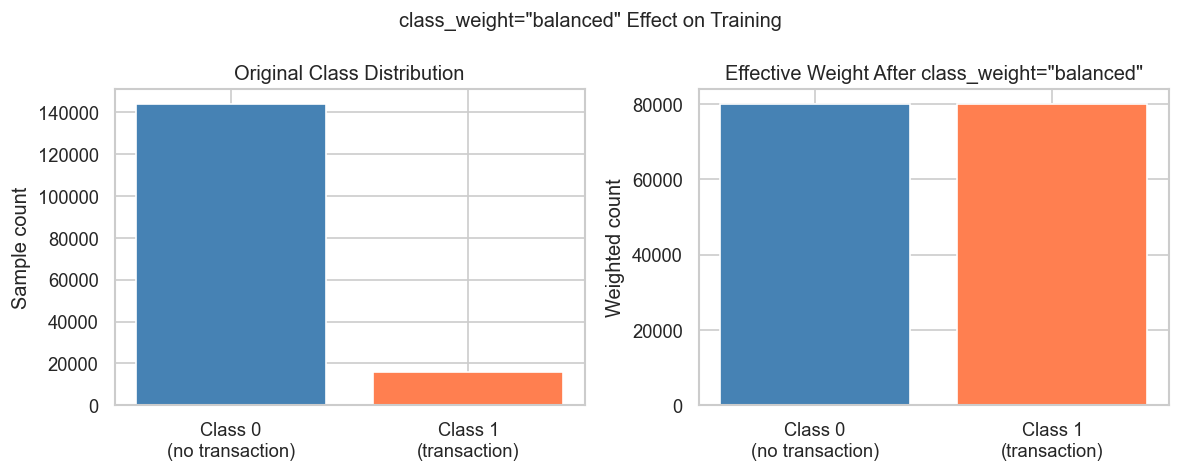

In [12]:
# Visualise class weights
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Original imbalance
axes[0].bar(['Class 0\n(no transaction)', 'Class 1\n(transaction)'],
            [y_train.value_counts()[0], y_train.value_counts()[1]],
            color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('Original Class Distribution')
axes[0].set_ylabel('Sample count')

# Effective weighted samples
effective = [y_train.value_counts()[0] * weights[0],
             y_train.value_counts()[1] * weights[1]]
axes[1].bar(['Class 0\n(no transaction)', 'Class 1\n(transaction)'],
            effective,
            color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Effective Weight After class_weight="balanced"')
axes[1].set_ylabel('Weighted count')

plt.suptitle('class_weight="balanced" Effect on Training', fontsize=12)
plt.tight_layout()
plt.savefig('../notebooks_images/11_class_weights.png', bbox_inches='tight')
plt.show()

## 6. Save Processed Data

We save two versions:
- **Scaled** → for Logistic Regression (requires scaling)
- **Unscaled** → for LightGBM (tree-based, does not need scaling)

Both include the aggregate features.

In [13]:
import joblib

# Save scaled versions (for Logistic Regression)
X_train_scaled.to_csv(f'{OUT_DIR}/X_train_scaled.csv', index=False)
X_val_scaled.to_csv(f'{OUT_DIR}/X_val_scaled.csv', index=False)

# Save unscaled versions with aggregate features (for LightGBM)
X_train_eng.to_csv(f'{OUT_DIR}/X_train.csv', index=False)
X_val_eng.to_csv(f'{OUT_DIR}/X_val.csv', index=False)

# Save labels
y_train.to_csv(f'{OUT_DIR}/y_train.csv', index=False)
y_val.to_csv(f'{OUT_DIR}/y_val.csv', index=False)

# Save scaler for reuse on test.csv
joblib.dump(scaler, f'{OUT_DIR}/robust_scaler.pkl')

print('Saved to data/processed/:')
for f in ['X_train.csv', 'X_val.csv', 'X_train_scaled.csv', 'X_val_scaled.csv',
          'y_train.csv', 'y_val.csv', 'robust_scaler.pkl']:
    print(f'  ✓ {f}')

Saved to data/processed/:
  ✓ X_train.csv
  ✓ X_val.csv
  ✓ X_train_scaled.csv
  ✓ X_val_scaled.csv
  ✓ y_train.csv
  ✓ y_val.csv
  ✓ robust_scaler.pkl


## 7. Feature Engineering Summary

| Step | Decision | Rationale |
|------|----------|-----------|
| Missing values | None — no action needed | Zero missing values found in EDA |
| Outliers | No clipping | Low skewness; LightGBM handles natively; RobustScaler handles for LR |
| Log transforms | Not applied | All features approximately symmetric (\|skew\| < 0.5) |
| Aggregate features | `row_mean`, `row_std`, `row_min`, `row_max`, `row_range`, `row_skew` | Capture row-level customer profile |
| Feature dropping | None — all 206 features retained | No multicollinearity; no zero-variance features |
| Scaling | RobustScaler (fit on train only) | Required for Logistic Regression; robust to outliers |
| Class imbalance | `class_weight='balanced'` | Simple, effective; no synthetic data needed |
| Train/val split | Stratified 80/20 | Preserves 10% positive rate in both sets |

### Files produced
```
data/processed/
├── X_train.csv          ← 160k rows, 206 features (LightGBM input)
├── X_val.csv            ← 40k rows, 206 features  (LightGBM validation)
├── X_train_scaled.csv   ← 160k rows, scaled       (Logistic Regression input)
├── X_val_scaled.csv     ← 40k rows, scaled        (Logistic Regression validation)
├── y_train.csv          ← 160k labels
├── y_val.csv            ← 40k labels
└── robust_scaler.pkl    ← fitted scaler (apply to test.csv later)
```

### Next: `03_modeling.ipynb`
- Train Logistic Regression baseline on scaled data
- Train LightGBM on unscaled data
- Compare AUC-ROC on validation set
- Tune LightGBM hyperparameters